In [56]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\crop_yield.csv")

## Understanding the data

df.shape

In [3]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [5]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

### no null values in the data set

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [8]:
df.corr(numeric_only=True)

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
Crop_Year,1.000000,-0.035686,0.003366,-0.011187,0.011169,-0.004657,0.002539
Area,-0.035686,1.000000,0.037441,-0.106054,0.973255,0.973479,0.001858
Production,0.003366,0.037441,1.000000,0.029879,0.039799,0.035171,0.570809
Annual_Rainfall,-0.011187,-0.106054,0.029879,1.000000,-0.109734,-0.097657,0.020761
Fertilizer,0.011169,0.973255,0.039799,-0.109734,1.000000,0.954991,0.002862
Pesticide,-0.004657,0.973479,0.035171,-0.097657,0.954991,1.000000,0.001782
Yield,0.002539,0.001858,0.570809,0.020761,0.002862,0.001782,1.000000


# Univarate Analysis

Crop_Year
1997     410
1998     646
1999     650
2000     772
2001     750
2002     815
2003     801
2004     787
2005     811
2006     823
2007     828
2008     847
2009     865
2010     859
2011     907
2012     894
2013     976
2014     965
2015     998
2016    1036
2017    1070
2018    1063
2019    1079
2020      37
Name: count, dtype: int64


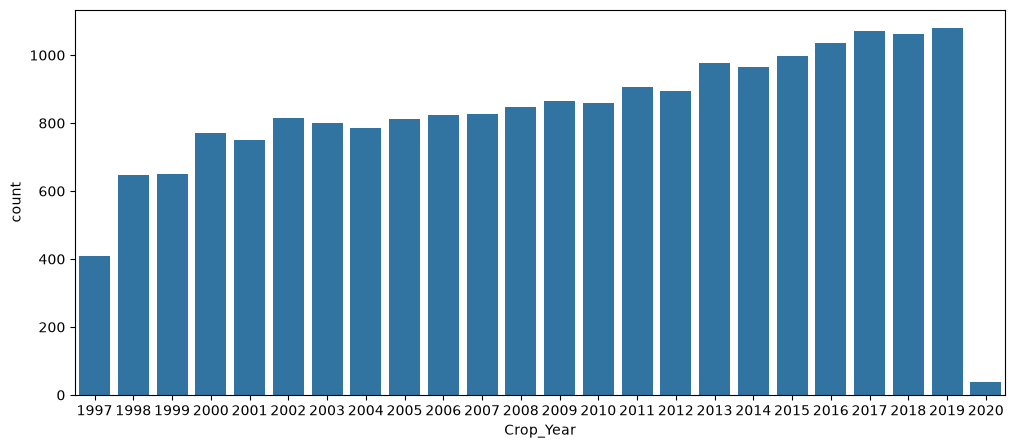

In [13]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Crop_Year')

print(df['Crop_Year'].value_counts().sort_index())

plt.show()

the count plot shows the number of records available for each Crop_Year in the dataset. It indicates how the data is distributed across different years, helping us identify years with more or fewer observations.

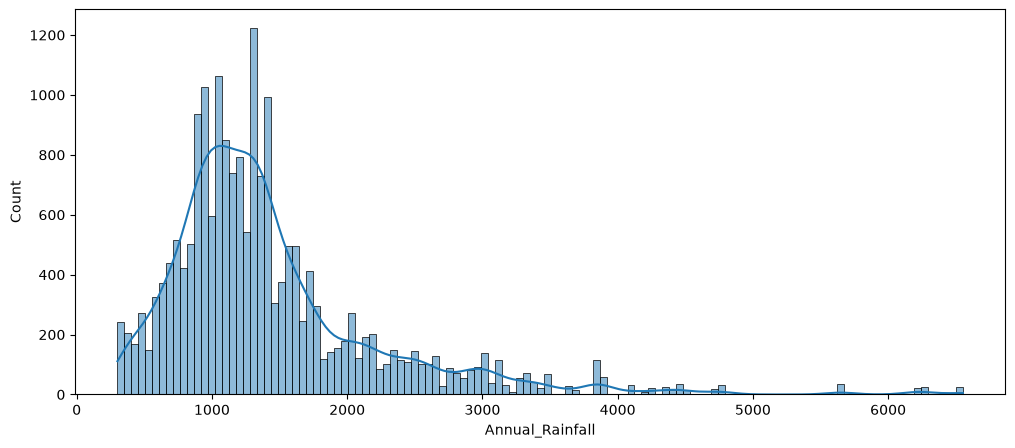

In [27]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='Annual_Rainfall' , kde = True)



plt.show()

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Production'}>],
       [<Axes: title={'center': 'Annual_Rainfall'}>,
        <Axes: title={'center': 'Fertilizer'}>],
       [<Axes: title={'center': 'Pesticide'}>,
        <Axes: title={'center': 'Yield'}>]], dtype=object)

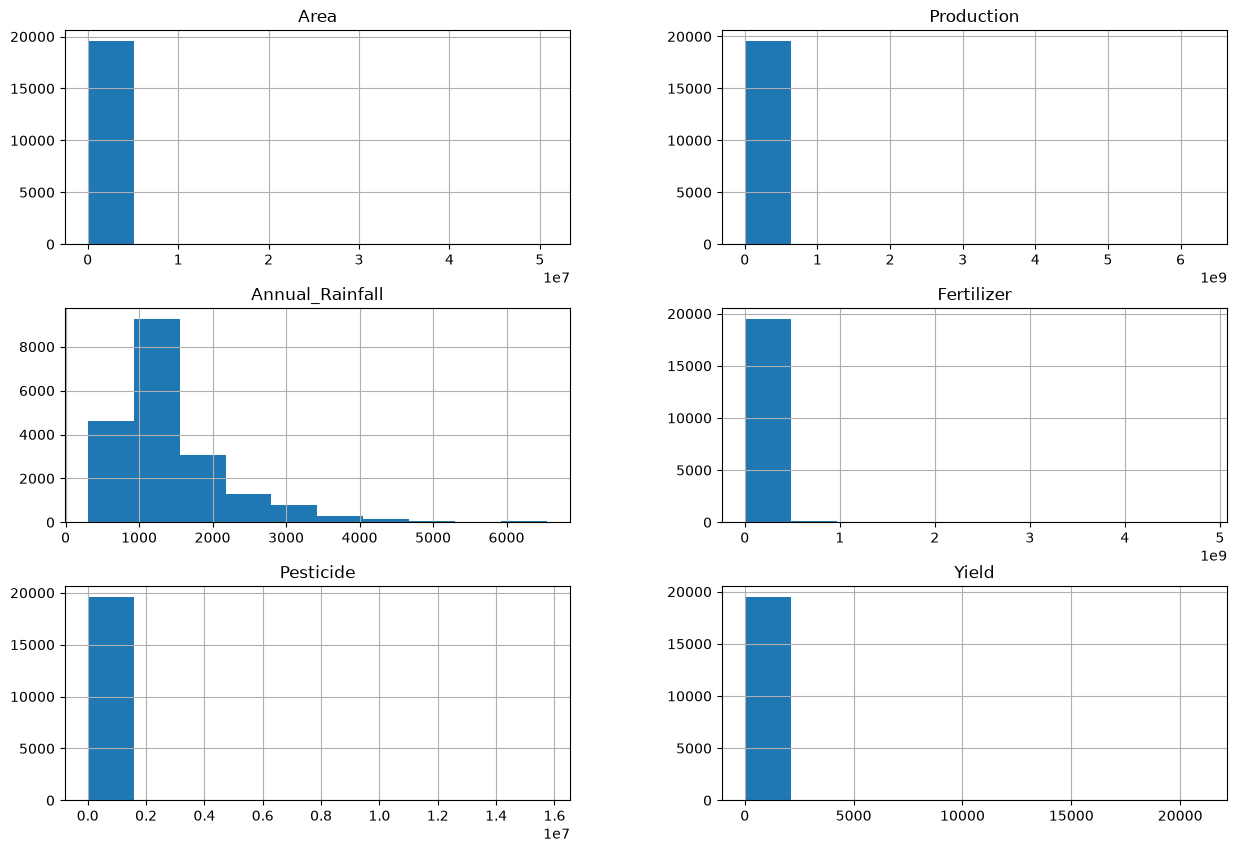

In [28]:
numerical = ['Area','Production','Annual_Rainfall',
             'Fertilizer','Pesticide','Yield']

df[numerical].hist(figsize=(15,10))

Crop
Arecanut                  162
Arhar/Tur                 508
Bajra                     524
Banana                    245
Barley                    297
Black pepper              126
Cardamom                   74
Cashewnut                 134
Castor seed               300
Coconut                   172
Coriander                 199
Cotton(lint)              476
Cowpea(Lobia)             134
Dry chillies              419
Garlic                    250
Ginger                    323
Gram                      490
Groundnut                 725
Guar seed                  63
Horse-gram                371
Jowar                     513
Jute                      181
Khesari                    75
Linseed                   308
Maize                     975
Masoor                    324
Mesta                     210
Moong(Green Gram)         740
Moth                      110
Niger seed                192
Oilseeds total             29
Onion                     454
Other  Rabi pulses        355
Other

<Axes: xlabel='count', ylabel='Crop'>

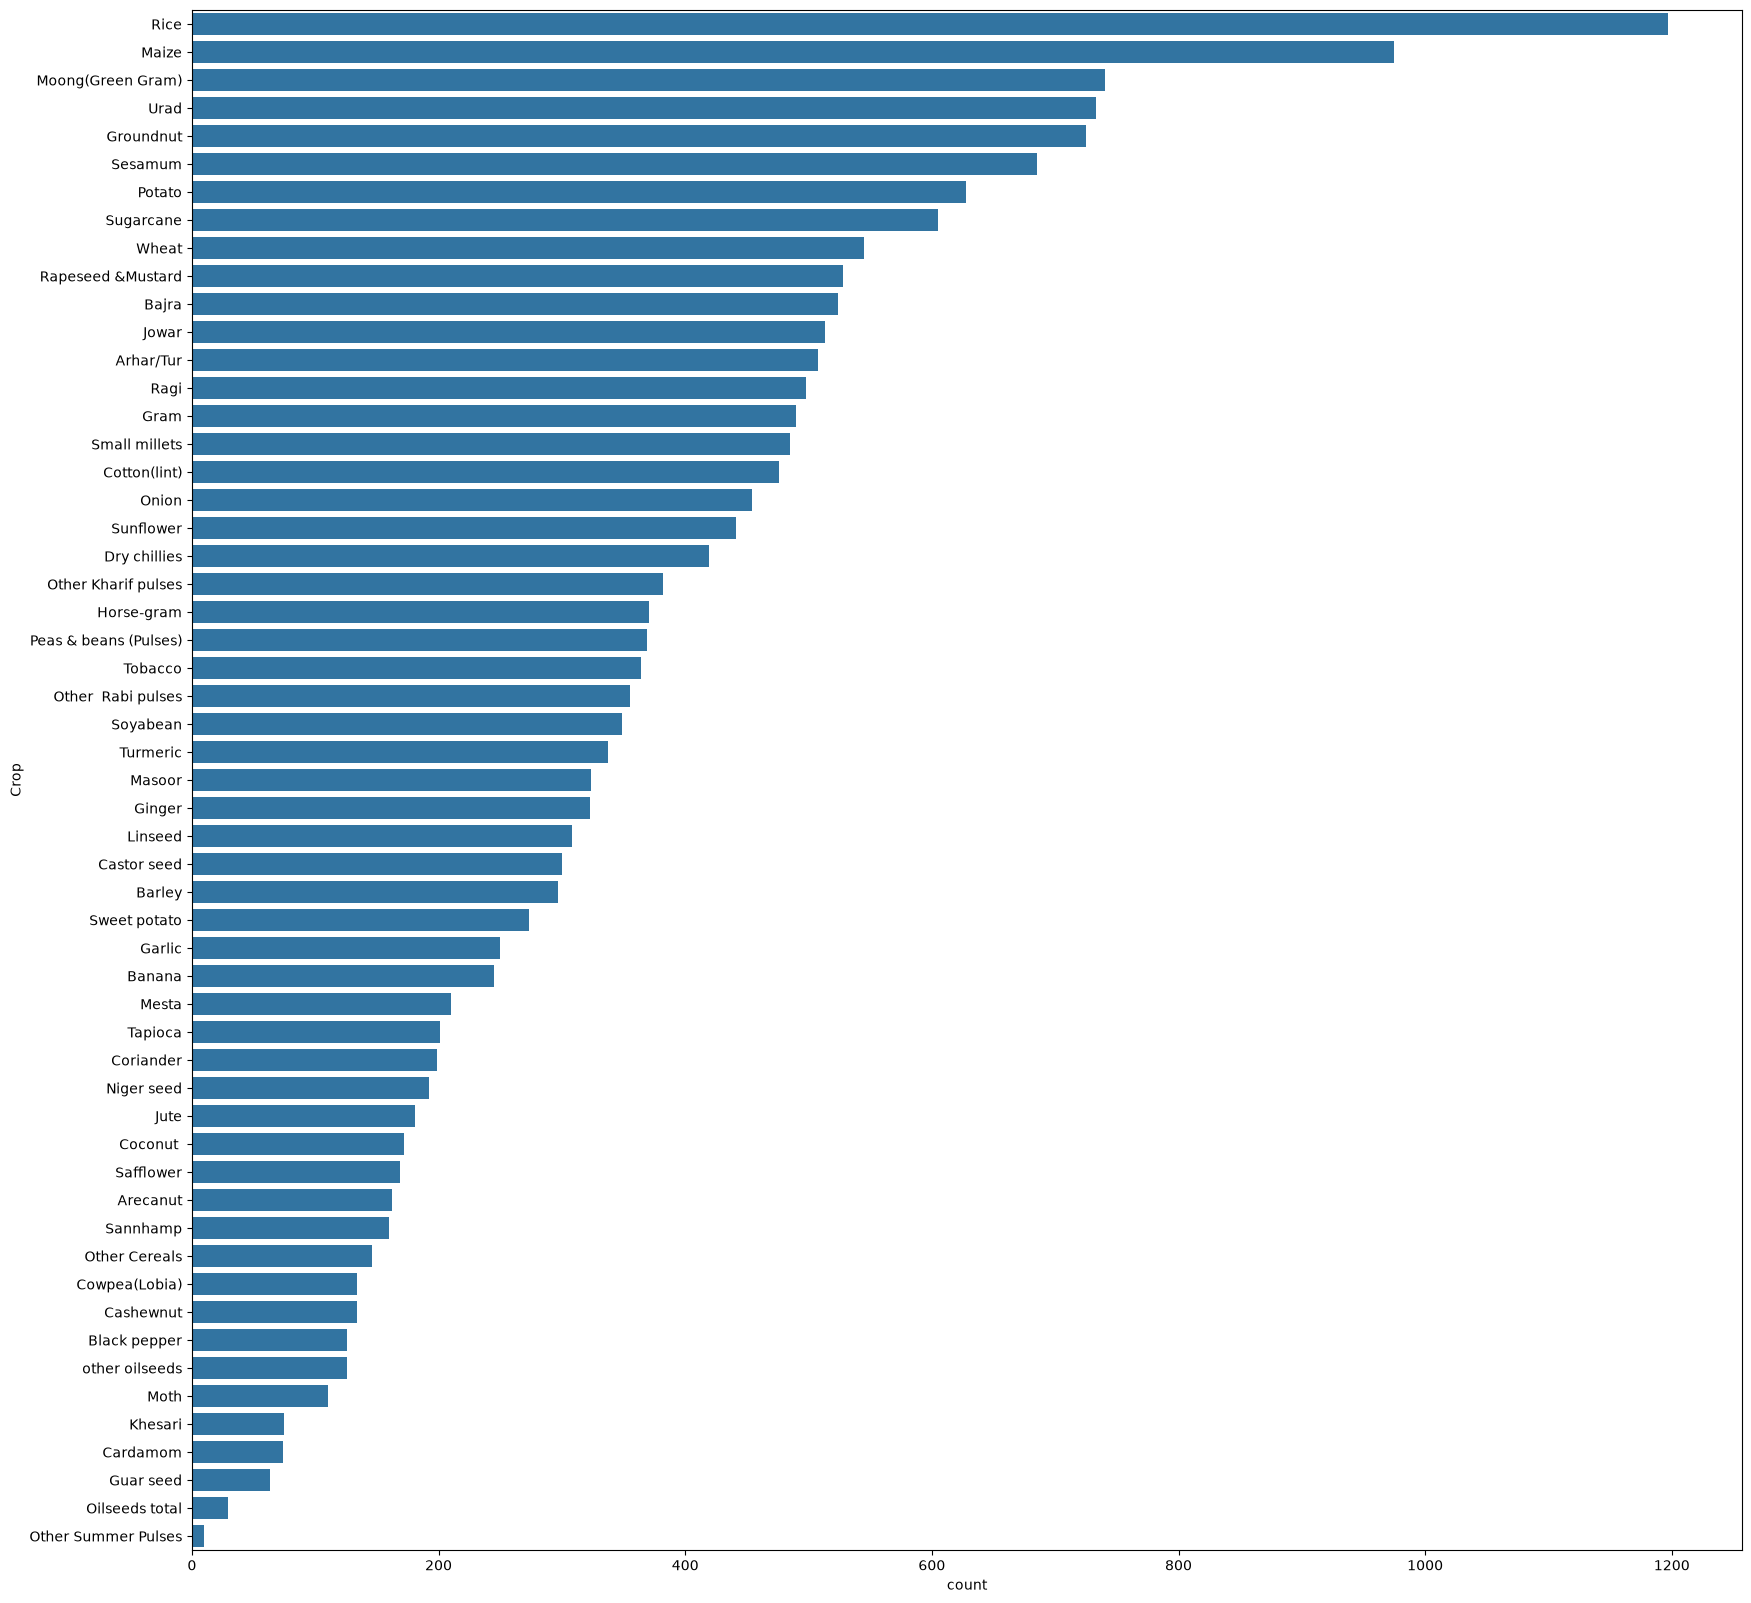

In [33]:
plt.figure(figsize=(20,20))
print(df['Crop'].value_counts().sort_index())
sns.countplot(data=df,y='Crop',order=df['Crop'].value_counts().index)

State
Andhra Pradesh       1266
Arunachal Pradesh     292
Assam                 731
Bihar                 896
Chhattisgarh          915
Delhi                 203
Goa                   246
Gujarat               817
Haryana               631
Himachal Pradesh      616
Jammu and Kashmir     631
Jharkhand             270
Karnataka            1432
Kerala                534
Madhya Pradesh        845
Maharashtra           770
Manipur               444
Meghalaya             649
Mizoram               416
Nagaland              689
Odisha                760
Puducherry            670
Punjab                397
Sikkim                226
Tamil Nadu            822
Telangana             397
Tripura               441
Uttar Pradesh         825
Uttarakhand           764
West Bengal          1094
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='State'>

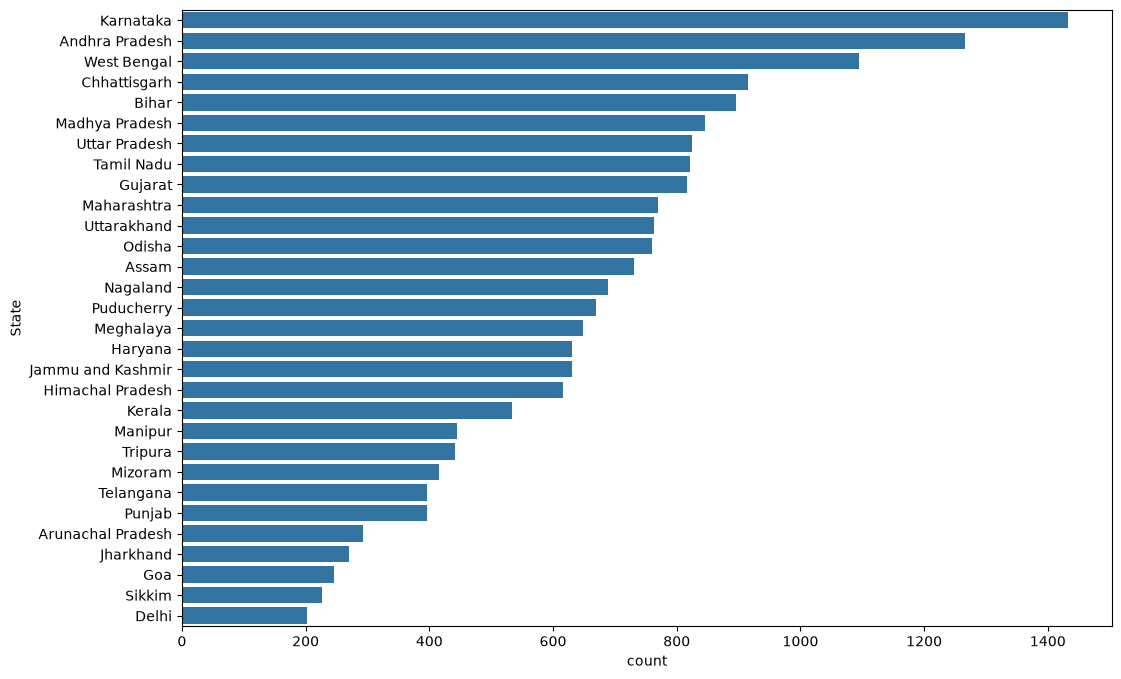

In [34]:
plt.figure(figsize=(12,8))
print(df['State'].value_counts().sort_index())
sns.countplot(data=df,y='State',order=df['State'].value_counts().index)

<Axes: xlabel='Season', ylabel='count'>

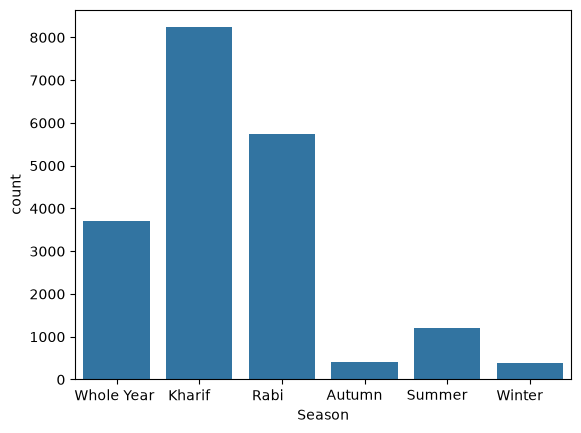

In [35]:
sns.countplot(data=df,x='Season')

In [36]:
df.skew(numeric_only=True)

Crop_Year          -0.162656
Area               21.858218
Production         19.299193
Annual_Rainfall     2.131785
Fertilizer         13.412599
Pesticide          25.635746
Yield              12.785265
dtype: float64

<Axes: >

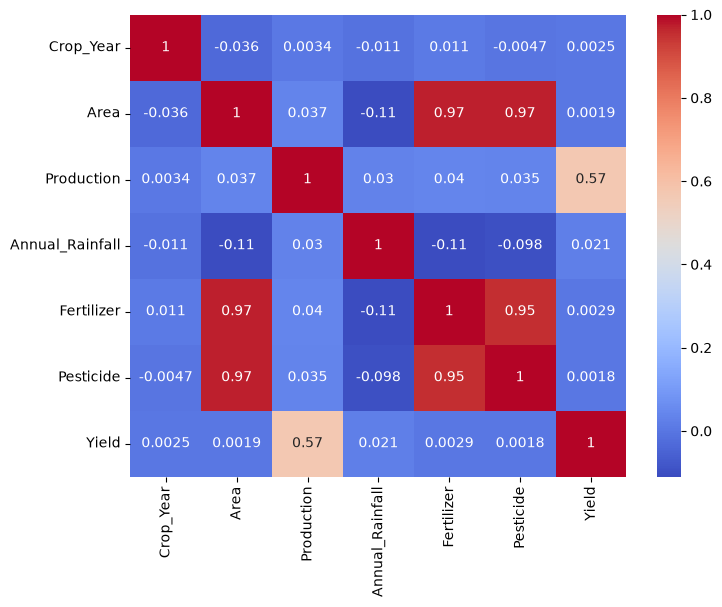

In [37]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')

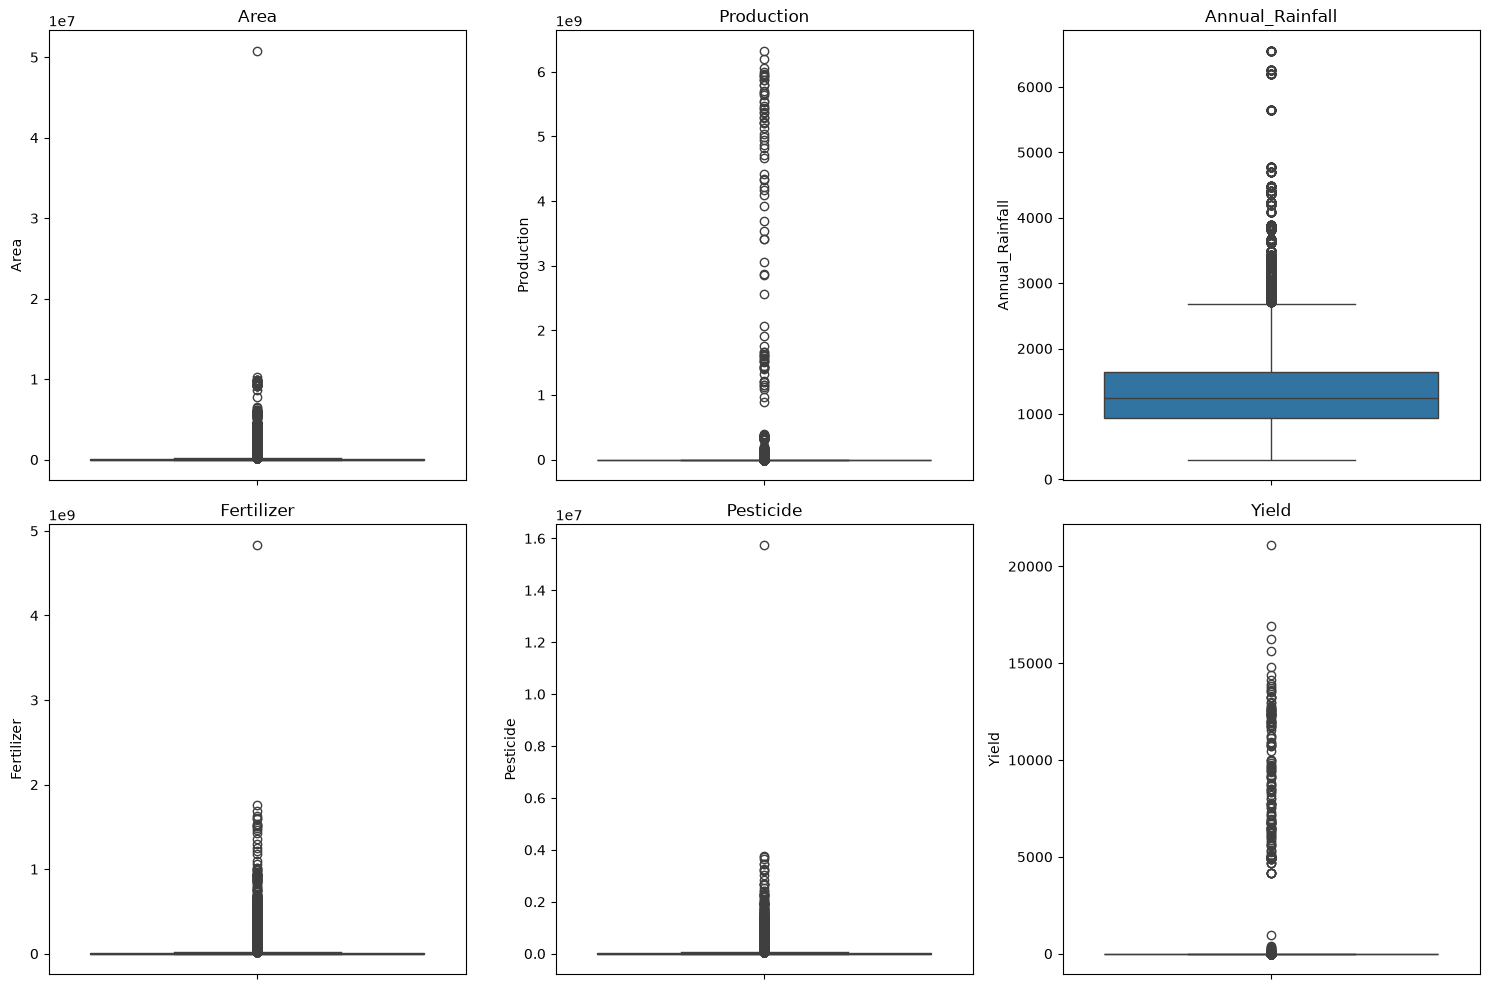

In [40]:
cols = ['Area', 'Production', 'Annual_Rainfall',
        'Fertilizer', 'Pesticide', 'Yield']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Yield vs Crop Analysis

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54],
 [Text(0, 0, 'Arecanut'),
  Text(1, 0, 'Arhar/Tur'),
  Text(2, 0, 'Castor seed'),
  Text(3, 0, 'Coconut '),
  Text(4, 0, 'Cotton(lint)'),
  Text(5, 0, 'Dry chillies'),
  Text(6, 0, 'Gram'),
  Text(7, 0, 'Jute'),
  Text(8, 0, 'Linseed'),
  Text(9, 0, 'Maize'),
  Text(10, 0, 'Mesta'),
  Text(11, 0, 'Niger seed'),
  Text(12, 0, 'Onion'),
  Text(13, 0, 'Other  Rabi pulses'),
  Text(14, 0, 'Potato'),
  Text(15, 0, 'Rapeseed &Mustard'),
  Text(16, 0, 'Rice'),
  Text(17, 0, 'Sesamum'),
  Text(18, 0, 'Small millets'),
  Text(19, 0, 'Sugarcane'),
  Text(20, 0, 'Sweet potato'),
  Text(21, 0, 'Tapioca'),
  Text(22, 0, 'Tobacco'),
  Text(23, 0, 'Turmeric'),
  Text(24, 0, 'Wheat'),
 

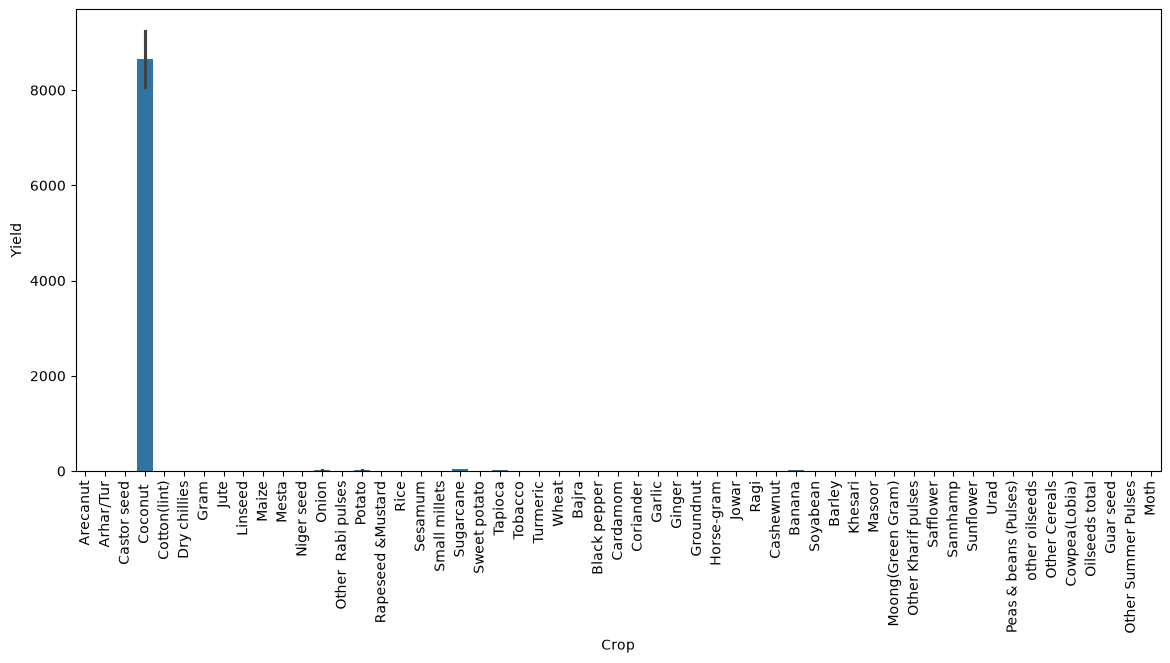

In [41]:
plt.figure(figsize=(14,6))
sns.barplot(data=df,
            x='Crop',
            y='Yield',
            estimator='mean')
plt.xticks(rotation=90)

## State vs Yield

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'Assam'),
  Text(1, 0, 'Karnataka'),
  Text(2, 0, 'Kerala'),
  Text(3, 0, 'Meghalaya'),
  Text(4, 0, 'West Bengal'),
  Text(5, 0, 'Puducherry'),
  Text(6, 0, 'Goa'),
  Text(7, 0, 'Andhra Pradesh'),
  Text(8, 0, 'Tamil Nadu'),
  Text(9, 0, 'Odisha'),
  Text(10, 0, 'Bihar'),
  Text(11, 0, 'Gujarat'),
  Text(12, 0, 'Madhya Pradesh'),
  Text(13, 0, 'Maharashtra'),
  Text(14, 0, 'Mizoram'),
  Text(15, 0, 'Punjab'),
  Text(16, 0, 'Uttar Pradesh'),
  Text(17, 0, 'Haryana'),
  Text(18, 0, 'Himachal Pradesh'),
  Text(19, 0, 'Tripura'),
  Text(20, 0, 'Nagaland'),
  Text(21, 0, 'Chhattisgarh'),
  Text(22, 0, 'Uttarakhand'),
  Text(23, 0, 'Jharkhand'),
  Text(24, 0, 'Delhi'),
  Text(25, 0, 'Manipur'),
  Text(26, 0, 'Jammu and Kashmir'),
  Text(27, 0, 'Telangana'),
  Text(28, 0, 'Arunachal Pradesh'),
  Text(29, 0, 'Si

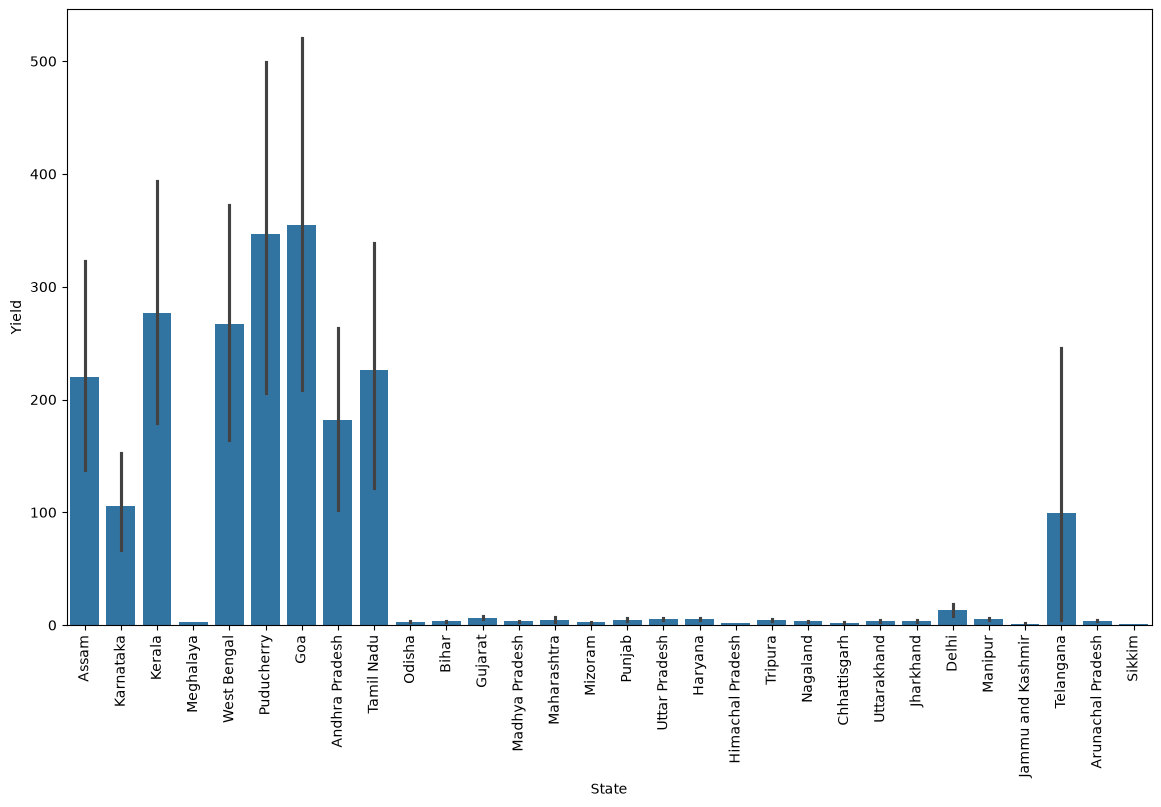

In [42]:
plt.figure(figsize=(14,8))
sns.barplot(data=df,
            x='State',
            y='Yield',
            estimator='mean')
plt.xticks(rotation=90)

## Anual_Rainfall vs Yield

<Axes: xlabel='Annual_Rainfall', ylabel='Yield'>

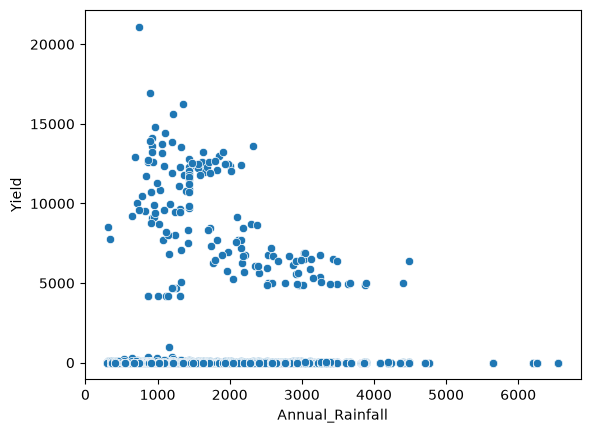

In [43]:
sns.scatterplot(data=df,
                x='Annual_Rainfall',
                y='Yield')

## Fertilizer vs Yield

<Axes: xlabel='Fertilizer', ylabel='Yield'>

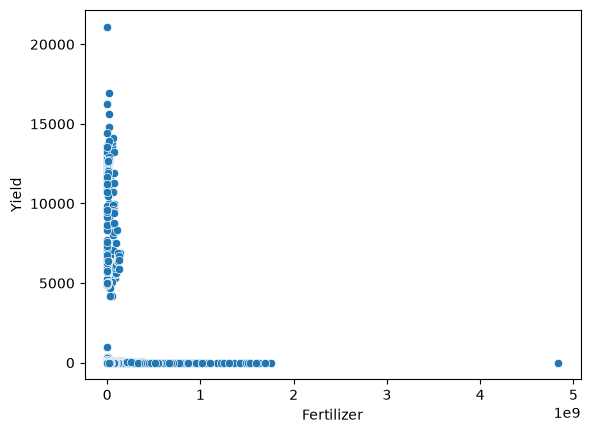

In [44]:
sns.scatterplot(data=df,
                x='Fertilizer',
                y='Yield')

## Pesticide vs Yield

<Axes: xlabel='Pesticide', ylabel='Yield'>

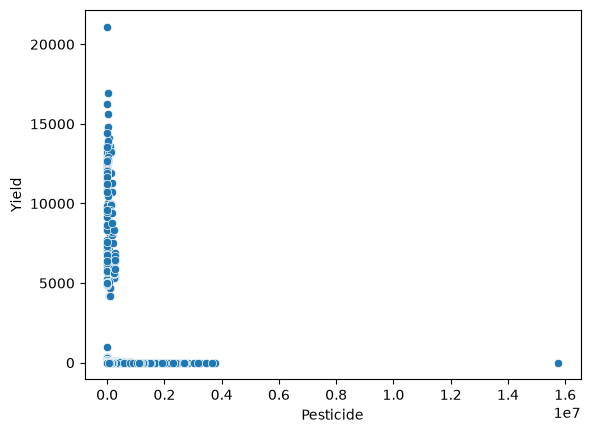

In [46]:
sns.scatterplot(data=df,
                x='Pesticide',
                y='Yield')

## Area vs Production

<Axes: xlabel='Area', ylabel='Production'>

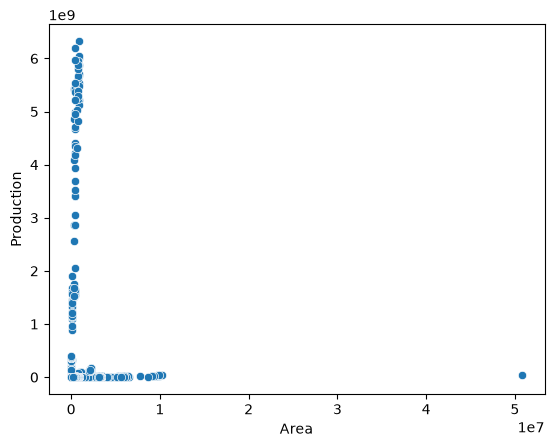

In [47]:
sns.scatterplot(data=df,
                x='Area',
                y='Production')

<Axes: xlabel='Crop_Year', ylabel='Yield'>

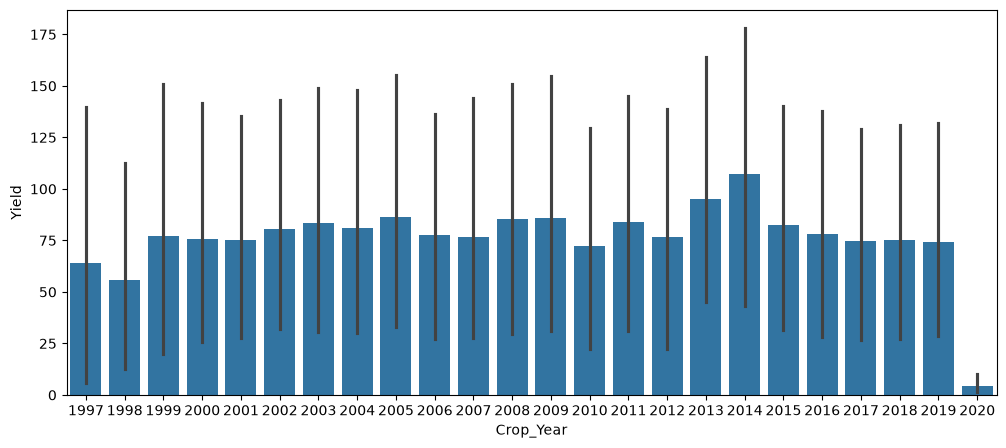

In [48]:
plt.figure(figsize=(12,5))
sns.barplot(data=df,
            x='Crop_Year',
            y='Yield',
            estimator='mean')

In [51]:
profile = ProfileReport(df,title="Crop Yield Dataset Profiling Report",explorative=True)

profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 121.84it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
profile.to_file("crop_yield_profiling_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
profile.to_notebook_iframe()

# Feature Engineering

## Dropping unessary columns

In [54]:
df = df.drop(columns=['Production'])

## label encoding

In [57]:

le = LabelEncoder()

categorical_cols = ['Crop', 'Season', 'State']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,0,1997,4,2,73814.0,2051.4,7024878.38,22882.34,0.796087
1,1,1997,1,2,6637.0,2051.4,631643.29,2057.47,0.710435
2,8,1997,1,2,796.0,2051.4,75755.32,246.76,0.238333
3,9,1997,4,2,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,11,1997,1,2,1739.0,2051.4,165500.63,539.09,0.420909


## Log Transform Skewed Features

In [59]:
import numpy as np

skewed_cols = ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [60]:
df['Yield'] = np.log1p(df['Yield'])

## Scale Numerical Features

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Area', 'Annual_Rainfall',
            'Fertilizer', 'Pesticide']

df[num_cols] = scaler.fit_transform(df[num_cols])

## Creating New Features

In [62]:
df['Fertilizer_per_Area'] = df['Fertilizer'] / (df['Area'] + 1)

In [63]:
df['Pesticide_per_Area'] = df['Pesticide'] / (df['Area'] + 1)

In [65]:
# =====================================================
# Feature Engineering Pipeline for Crop Yield Dataset
# =====================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# -------------------------
# Create a copy of dataset
# -------------------------
df_fe = df.copy()

# -------------------------
# Drop Production (if exists)
# -------------------------
df_fe.drop(columns=['Production'], errors='ignore', inplace=True)

# -------------------------
# Encode Categorical Features
# -------------------------
categorical_cols = ['Crop', 'Season', 'State']

label_encoders = {}

for col in categorical_cols:
    if col in df_fe.columns:
        le = LabelEncoder()
        df_fe[col] = le.fit_transform(df_fe[col])
        label_encoders[col] = le

# -------------------------
# Create New Features
# -------------------------

# Years since first recorded year
df_fe['Years_Since_1997'] = df_fe['Crop_Year'] - df_fe['Crop_Year'].min()

# Fertilizer per Area
df_fe['Fertilizer_per_Area'] = (
    df_fe['Fertilizer'] / (df_fe['Area'] + 1)
)

# Pesticide per Area
df_fe['Pesticide_per_Area'] = (
    df_fe['Pesticide'] / (df_fe['Area'] + 1)
)

# Rainfall per Area
df_fe['Rainfall_per_Area'] = (
    df_fe['Annual_Rainfall'] / (df_fe['Area'] + 1)
)

# -------------------------
# Log Transformation
# -------------------------

log_cols = [
    'Area',
    'Annual_Rainfall',
    'Fertilizer',
    'Pesticide',
    'Fertilizer_per_Area',
    'Pesticide_per_Area',
    'Rainfall_per_Area'
]

for col in log_cols:
    if col in df_fe.columns:
        df_fe[col] = np.log1p(df_fe[col])

# -------------------------
# Feature Scaling
# -------------------------

scale_cols = [
    'Crop_Year',
    'Area',
    'Annual_Rainfall',
    'Fertilizer',
    'Pesticide',
    'Years_Since_1997',
    'Fertilizer_per_Area',
    'Pesticide_per_Area',
    'Rainfall_per_Area'
]

scaler = StandardScaler()

available_cols = [col for col in scale_cols if col in df_fe.columns]

df_fe[available_cols] = scaler.fit_transform(df_fe[available_cols])

# -------------------------
# Separate Features & Target
# -------------------------

X = df_fe.drop(columns=['Yield'])
y = df_fe['Yield']

# -------------------------
# Display Results
# -------------------------

print("="*50)
print(" Feature Engineering Completed Successfully ")
print("="*50)

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

print("\nFirst Five Rows:")
display(df_fe.head())

 Feature Engineering Completed Successfully 

Feature Matrix Shape : (19689, 12)
Target Shape         : (19689,)

Features Used:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Fertilizer_per_Area', 'Pesticide_per_Area', 'Years_Since_1997', 'Rainfall_per_Area']

First Five Rows:


C:\Users\gsksd\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield,Fertilizer_per_Area,Pesticide_per_Area,Years_Since_1997,Rainfall_per_Area
0,0,-1.866375,4,2,0.616544,0.892256,0.547118,0.653853,0.585610,-0.011136,0.06204,-1.866375,0.323538
1,1,-1.866375,1,2,-0.089477,0.892256,-0.245922,-0.038059,0.536748,-0.621306,-0.40196,-1.866375,0.594501
2,8,-1.866375,1,2,-1.798846,0.892256,-2.789075,-1.608655,0.213766,NaN,NaN,-1.866375,1.632530
3,9,-1.866375,4,2,0.284792,0.892256,0.180520,0.327110,8.563896,-0.211787,-0.09726,-1.866375,0.438741
4,11,-1.866375,1,2,-0.849192,0.892256,-1.187131,-0.761894,0.351297,NaN,NaN,-1.866375,0.995095


In [66]:
df

,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield,Fertilizer_per_Area,Pesticide_per_Area
0,0,1997,4,2,0.724468,0.962449,0.608487,0.785077,0.585610,0.352855,0.455257
1,1,1997,1,2,-0.089710,0.962449,-0.202102,-0.039844,0.536748,-0.222020,-0.043771
2,8,1997,1,2,-0.806191,0.962449,-0.915752,-0.765029,0.213766,-4.725016,-3.947330
3,9,1997,4,2,0.277240,0.962449,0.163243,0.331918,8.563896,0.127809,0.259872
4,11,1997,1,2,-0.542278,0.962449,-0.652791,-0.498118,0.351297,-1.426176,-1.088257
...,...,...,...,...,...,...,...,...,...,...,...
19684,44,1998,1,19,-0.260833,0.339675,-0.359898,-0.235994,0.405465,-0.486896,-0.319270
19685,53,1998,2,19,-0.729159,0.339675,-0.826383,-0.709932,1.386294,-3.051167,-2.621208
19686,24,1997,1,10,1.210476,0.142713,1.092330,1.277552,0.826366,0.494160,0.577953
19687,40,1997,1,10,1.169937,0.142713,1.051971,1.236473,0.016529,0.484793,0.569820


## model training 

In [67]:
# ============================================================
# Crop Yield Prediction - Model Training & Evaluation
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)
print("="*60)

# ============================================================
# Models
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

# ============================================================
# Training + Evaluation
# ============================================================

results = []

best_model = None
best_score = -100

print("\nTraining Models...\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"{name} Trained Successfully")

    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\n================ MODEL COMPARISON ================\n")

display(results_df)

# ============================================================
# Best Model
# ============================================================

print("\nBest Model :", best_model_name)
print("Best R² Score :", round(best_score,4))

# ============================================================
# Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 10 Important Features\n")

    display(importance.head(10))

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance.head(10),
        x="Importance",
        y="Feature",
        palette="viridis"
    )

    plt.title("Top 10 Feature Importance")
    plt.show()

# ============================================================
# Actual vs Predicted Plot
# ============================================================

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")


plt.title("Actual vs Predicted Yield")

plt.show()


Train Shape : (15751, 12)
Test Shape  : (3938, 12)

Training Models...



ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## saving the model

In [ ]:

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "crop_yield_model.pkl")

print("\nModel saved as crop_yield_model.pkl")

# ============================================================
# Save Feature Engineered Dataset (Optional)
# ============================================================

df_fe.to_csv("feature_engineered_crop_dataset.csv", index=False)

print("Feature engineered dataset saved successfully.")